# quantum_digital_signature_2
## A corrected, beginner-friendly Quantum Digital Signature notebook

This notebook is a cleaned-up educational implementation of a
Gottesman-Chuang-style Quantum Digital Signature (QDS) demo.

The first notebook was useful as a sketch, but it had several important
problems: stale outputs, ignored key bits, formulas that did not match
the multi-qubit code, thresholds scaled by only `M` instead of by the
full number of checks, and a forgery plot whose math did not match the
simulated event.

This version fixes those issues and keeps the language beginner-friendly.
It is still a simulator demo, not a production cryptographic system.

## Step 0: Load libraries

We first import the Python libraries used in the notebook.

- `numpy` handles arrays and reproducible random numbers.
- `matplotlib` draws plots.
- `qiskit` builds the quantum circuits.
- `qiskit-aer` simulates measurements.
- `Statevector` lets us calculate exact probabilities, which helps us
  avoid confusing random simulator noise with protocol behavior.

In [1]:
%matplotlib inline

import math
import warnings
from typing import Dict, List, Tuple

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

warnings.filterwarnings("ignore", category=DeprecationWarning)

print("=" * 64)
print("Library versions")
print("=" * 64)
print(f"qiskit      : {qiskit.__version__}")
print(f"qiskit-aer  : {qiskit_aer.__version__}")
print(f"numpy       : {np.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print("=" * 64)

Library versions
qiskit      : 2.4.1
qiskit-aer  : 0.17.2
numpy       : 2.4.4
matplotlib  : 3.10.9


## Step 1: What this implementation fixes

The core idea is simple: Alice owns classical private keys, and each
private key is mapped to a quantum public-key state. To sign a message,
Alice reveals the private keys corresponding to the message bits. A
verifier checks whether the revealed keys recreate the public states.

This version makes five important corrections:

1. Every bit of the private key is used.
2. Multi-qubit overlap formulas match the actual multi-qubit circuit.
3. Verification thresholds are scaled by all checks, `message_length * M`.
4. Randomness is reproducible for teaching and testing.
5. The forgery analysis uses the same acceptance rule as verification.

In [2]:
Key = Tuple[int, ...]


class QuantumDigitalSignatureV2:
    """Educational QDS simulator with corrected bookkeeping and formulas."""

    def __init__(
        self,
        n_qubits: int,
        key_length: int,
        copies_per_bit: int,
        seed: int = 2026,
        shots: int = 4096,
        verification_pass_threshold: float = 0.99,
    ) -> None:
        if n_qubits <= 0:
            raise ValueError("n_qubits must be positive.")
        if key_length < n_qubits:
            raise ValueError("key_length must be at least n_qubits.")
        if copies_per_bit <= 0:
            raise ValueError("copies_per_bit must be positive.")
        if not (0.0 < verification_pass_threshold <= 1.0):
            raise ValueError("verification_pass_threshold must be in (0, 1].")

        self.n_qubits = int(n_qubits)
        self.L = int(key_length)
        self.M = int(copies_per_bit)
        self.seed = int(seed)
        self.shots = int(shots)
        self.verification_pass_threshold = float(verification_pass_threshold)
        self.rng = np.random.default_rng(self.seed)
        self.simulator = AerSimulator(seed_simulator=self.seed)

        self.chunk_slices = self._make_chunk_slices()
        self.chunk_sizes = [sl.stop - sl.start for sl in self.chunk_slices]

        self.message_length: int | None = None
        self.private_keys: Dict[int, List[Tuple[Key, Key]]] = {}
        self.public_keys: Dict[int, List[Tuple[QuantumCircuit, QuantumCircuit]]] = {}

    def _make_chunk_slices(self) -> List[slice]:
        """Split the L key bits across n qubits without dropping any bits."""
        base, remainder = divmod(self.L, self.n_qubits)
        sizes = [base + (1 if q < remainder else 0) for q in range(self.n_qubits)]

        slices: List[slice] = []
        start = 0
        for size in sizes:
            stop = start + size
            slices.append(slice(start, stop))
            start = stop

        assert start == self.L, "Internal error: key partition lost bits."
        return slices

    @staticmethod
    def _validate_message(message_bits: str) -> str:
        if not isinstance(message_bits, str) or not message_bits:
            raise ValueError("message_bits must be a non-empty binary string.")
        if any(bit not in "01" for bit in message_bits):
            raise ValueError("message_bits may contain only '0' and '1'.")
        return message_bits

    def _validate_key(self, key: Tuple[int, ...] | List[int] | np.ndarray) -> Key:
        key_tuple = tuple(int(bit) for bit in key)
        if len(key_tuple) != self.L:
            raise ValueError(f"Each key must contain exactly {self.L} bits.")
        if any(bit not in (0, 1) for bit in key_tuple):
            raise ValueError("Keys may contain only 0 and 1.")
        return key_tuple

    def _random_key(self) -> Key:
        return tuple(int(bit) for bit in self.rng.integers(0, 2, size=self.L))

    @staticmethod
    def key_to_int(key: Key) -> int:
        return int("".join(str(bit) for bit in key), 2)

    @staticmethod
    def _bits_to_int(bits: Tuple[int, ...]) -> int:
        return int("".join(str(bit) for bit in bits), 2) if bits else 0

    def prepare_state(self, key: Tuple[int, ...] | List[int] | np.ndarray) -> QuantumCircuit:
        """Map a classical key to an n-qubit product state.

        Each qubit receives one contiguous chunk of the key. If the key
        length is not divisible by the number of qubits, earlier qubits
        receive one extra bit. No key bits are ignored.
        """
        key_tuple = self._validate_key(key)
        qc = QuantumCircuit(self.n_qubits, name="f_k")

        for qubit, sl in enumerate(self.chunk_slices):
            chunk = key_tuple[sl]
            j_q = self._bits_to_int(chunk)
            theta_q = math.pi / (2 ** len(chunk))
            qc.ry(2.0 * j_q * theta_q, qubit)

        return qc

    @staticmethod
    def statevector(circuit: QuantumCircuit) -> Statevector:
        return Statevector.from_instruction(circuit)

    @classmethod
    def overlap_squared_from_circuits(
        cls,
        circuit_a: QuantumCircuit,
        circuit_b: QuantumCircuit,
    ) -> float:
        state_a = cls.statevector(circuit_a).data
        state_b = cls.statevector(circuit_b).data
        return float(abs(np.vdot(state_a, state_b)) ** 2)

    def overlap_squared_from_keys(self, key_a: Key, key_b: Key) -> float:
        return self.overlap_squared_from_circuits(
            self.prepare_state(key_a),
            self.prepare_state(key_b),
        )

    def theoretical_overlap_squared(self, key_a: Key, key_b: Key) -> float:
        """Closed-form overlap for the implemented multi-qubit state map."""
        key_a = self._validate_key(key_a)
        key_b = self._validate_key(key_b)
        overlap_sq = 1.0

        for sl in self.chunk_slices:
            chunk_a = key_a[sl]
            chunk_b = key_b[sl]
            j_a = self._bits_to_int(chunk_a)
            j_b = self._bits_to_int(chunk_b)
            theta = math.pi / (2 ** len(chunk_a))
            overlap_sq *= math.cos((j_a - j_b) * theta) ** 2

        return float(overlap_sq)

    def generate_key_material(self, message_length: int) -> Tuple[dict, dict]:
        """Generate private and public key material for a fixed message length."""
        if message_length <= 0:
            raise ValueError("message_length must be positive.")

        self.message_length = int(message_length)
        self.private_keys = {}
        self.public_keys = {}

        for bit_index in range(self.message_length):
            self.private_keys[bit_index] = []
            self.public_keys[bit_index] = []

            for _ in range(self.M):
                k0 = self._random_key()
                k1 = self._random_key()
                while k1 == k0:
                    k1 = self._random_key()

                self.private_keys[bit_index].append((k0, k1))
                self.public_keys[bit_index].append((
                    self.prepare_state(k0),
                    self.prepare_state(k1),
                ))

        return self.private_keys, self.public_keys

    def make_signature(self, message_bits: str) -> dict:
        """Sign a binary message by revealing the matching private keys."""
        message_bits = self._validate_message(message_bits)
        if self.message_length is None:
            raise ValueError("Call generate_key_material() before signing.")
        if len(message_bits) != self.message_length:
            raise ValueError("Message length does not match generated key material.")

        signature = {}
        for bit_index, bit_char in enumerate(message_bits):
            bit_value = int(bit_char)
            revealed_keys = []
            for copy_index in range(self.M):
                k0, k1 = self.private_keys[bit_index][copy_index]
                revealed_keys.append(list(k0 if bit_value == 0 else k1))

            signature[bit_index] = {
                "bit_value": bit_value,
                "keys": revealed_keys,
            }

        return {"message": message_bits, "signature": signature}

    def verify_signature(self, signed_message: dict, c1: float, c2: float) -> dict:
        """Verify a signature with thresholds scaled by all checks."""
        if not (0.0 <= c1 < c2 <= 1.0):
            raise ValueError("Thresholds must satisfy 0 <= c1 < c2 <= 1.")
        if self.message_length is None:
            raise ValueError("Call generate_key_material() before verification.")

        message_bits = self._validate_message(signed_message["message"])
        if len(message_bits) != self.message_length:
            raise ValueError("Signed message length does not match generated key material.")

        signature = signed_message["signature"]
        total_checks = len(message_bits) * self.M
        failures = 0
        pass_probabilities = []

        for bit_index, bit_char in enumerate(message_bits):
            bit_value = int(bit_char)
            sig_data = signature.get(bit_index)
            if sig_data is None:
                raise ValueError(f"Missing signature data for bit index {bit_index}.")
            if int(sig_data["bit_value"]) != bit_value:
                raise ValueError(
                    f"Signature bit metadata does not match the message at index {bit_index}."
                )
            if len(sig_data["keys"]) != self.M:
                raise ValueError(f"Bit index {bit_index} must reveal exactly {self.M} keys.")

            for copy_index in range(self.M):
                revealed_key = self._validate_key(sig_data["keys"][copy_index])
                stored_public_state = self.public_keys[bit_index][copy_index][bit_value]
                rebuilt_state = self.prepare_state(revealed_key)
                pass_probability = self.overlap_squared_from_circuits(
                    stored_public_state,
                    rebuilt_state,
                )
                pass_probabilities.append(pass_probability)

                if pass_probability < self.verification_pass_threshold:
                    failures += 1

        threshold_c1 = c1 * total_checks
        threshold_c2 = c2 * total_checks

        if failures <= threshold_c1:
            verdict = "1-ACC"
            verdict_full = "Accepted as valid and transferable."
        elif failures < threshold_c2:
            verdict = "0-ACC"
            verdict_full = "Accepted as valid for this verifier, but not transferable."
        else:
            verdict = "REJ"
            verdict_full = "Rejected as invalid."

        return {
            "failures": failures,
            "total_checks": total_checks,
            "failure_rate": failures / total_checks,
            "threshold_c1": threshold_c1,
            "threshold_c2": threshold_c2,
            "verdict": verdict,
            "verdict_full": verdict_full,
            "pass_probabilities": pass_probabilities,
        }

    def swap_test(self, circuit_a: QuantumCircuit, circuit_b: QuantumCircuit) -> dict:
        """Run a SWAP test and also return the exact theoretical value."""
        n = self.n_qubits
        qc = QuantumCircuit(2 * n + 1, 1)
        qc.h(0)
        qc.compose(circuit_a, qubits=list(range(1, n + 1)), inplace=True)
        qc.compose(circuit_b, qubits=list(range(n + 1, 2 * n + 1)), inplace=True)
        for qubit in range(n):
            qc.cswap(0, qubit + 1, n + qubit + 1)
        qc.h(0)
        qc.measure(0, 0)

        overlap_sq = self.overlap_squared_from_circuits(circuit_a, circuit_b)
        exact_p_zero = (1.0 + overlap_sq) / 2.0

        transpiled = transpile(qc, self.simulator)
        job = self.simulator.run(transpiled, shots=self.shots)
        counts = job.result().get_counts()
        measured_p_zero = counts.get("0", 0) / self.shots

        return {
            "circuit": qc,
            "counts": counts,
            "overlap_squared": overlap_sq,
            "p_zero_exact": exact_p_zero,
            "p_zero_measured": measured_p_zero,
        }

    def random_signature_guess(self, message_bits: str, rng: np.random.Generator) -> dict:
        """Create a forged signature by guessing all revealed keys uniformly."""
        message_bits = self._validate_message(message_bits)
        if len(message_bits) != self.message_length:
            raise ValueError("Forged message length does not match generated key material.")

        signature = {}
        for bit_index, bit_char in enumerate(message_bits):
            signature[bit_index] = {"bit_value": int(bit_char), "keys": []}
            for _ in range(self.M):
                guessed = tuple(int(bit) for bit in rng.integers(0, 2, size=self.L))
                signature[bit_index]["keys"].append(list(guessed))

        return {"message": message_bits, "signature": signature}


print("QuantumDigitalSignatureV2 class defined.")

QuantumDigitalSignatureV2 class defined.


## Step 2: Choose clear demo parameters

We choose a small enough setup to run quickly, but we keep the parameter
bookkeeping honest.

- `N_QUBITS = 4`: every public state has four qubits.
- `L = 28`: every private key has 28 bits.
- `M = 5`: each message bit uses five independent key pairs.
- `SEED = 2026`: the demo is reproducible.

The key length is divisible by the qubit count here, so each qubit gets
seven key bits. The class also works when the division is uneven.

In [3]:
N_QUBITS = 4
L = 28
M = 5
SEED = 2026
SHOTS = 4096

message_bits = "101100101"

qds = QuantumDigitalSignatureV2(
    n_qubits=N_QUBITS,
    key_length=L,
    copies_per_bit=M,
    seed=SEED,
    shots=SHOTS,
    verification_pass_threshold=0.99,
)

margin = L - N_QUBITS * M
worst_case_delta = math.cos(math.pi / (2 ** max(qds.chunk_sizes)))

print("=" * 64)
print("QDS demo parameters")
print("=" * 64)
print(f"message_bits        : {message_bits}")
print(f"message length      : {len(message_bits)}")
print(f"n_qubits            : {qds.n_qubits}")
print(f"L                   : {qds.L}")
print(f"M                   : {qds.M}")
print(f"random seed         : {qds.seed}")
print(f"shots               : {qds.shots}")
print(f"key chunk sizes     : {qds.chunk_sizes}")
print(f"Holevo margin L-n*M : {margin}")
print(f"worst-case overlap  : {worst_case_delta:.8f}")
print()
print("Important note:")
print("The Holevo margin is a useful sanity check, not a complete proof of security.")
print("This notebook is a corrected simulator demonstration, not a deployable QDS system.")
print("=" * 64)

QDS demo parameters
message_bits        : 101100101
message length      : 9
n_qubits            : 4
L                   : 28
M                   : 5
random seed         : 2026
shots               : 4096
key chunk sizes     : [7, 7, 7, 7]
Holevo margin L-n*M : 8
worst-case overlap  : 0.99969882

Important note:
The Holevo margin is a useful sanity check, not a complete proof of security.
This notebook is a corrected simulator demonstration, not a deployable QDS system.


## Step 3: Generate key material

For each bit position, Alice creates `M` pairs of private keys:

\[
(k_0^{(i)}, k_1^{(i)}).
\]

The key `k_0` is used if the message bit is `0`, and `k_1` is used if
the message bit is `1`.

The corresponding public keys are quantum circuits that prepare
`|f_k>`. In a real QDS system these would be quantum states distributed
to verifiers. In this simulator we store circuits so the example can be
rerun and checked exactly.

Generated key material
bit positions : 9
copies/bit    : 5
key pairs     : 45
public states : 90

First two key pairs for bit position 0
----------------------------------------------------------------
copy 0
  k0 first 14 bits : [1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1] ... int=151776375
  k1 first 14 bits : [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1] ... int=125879841
copy 1
  k0 first 14 bits : [0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0] ... int=46079556
  k1 first 14 bits : [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1] ... int=19297321

Example public-key circuit for bit position 0, copy 0, k1:


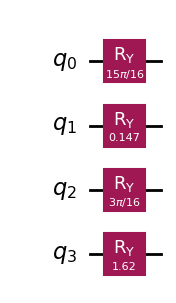

In [4]:
private_keys, public_keys = qds.generate_key_material(message_length=len(message_bits))

print("Generated key material")
print("=" * 64)
print(f"bit positions : {len(private_keys)}")
print(f"copies/bit    : {qds.M}")
print(f"key pairs     : {len(private_keys) * qds.M}")
print(f"public states : {len(private_keys) * qds.M * 2}")
print()

print("First two key pairs for bit position 0")
print("-" * 64)
for copy_index in range(2):
    k0, k1 = private_keys[0][copy_index]
    print(f"copy {copy_index}")
    print(f"  k0 first 14 bits : {list(k0[:14])} ... int={qds.key_to_int(k0)}")
    print(f"  k1 first 14 bits : {list(k1[:14])} ... int={qds.key_to_int(k1)}")

print()
print("Example public-key circuit for bit position 0, copy 0, k1:")
example_circuit = public_keys[0][0][1]
example_figure = example_circuit.draw("mpl", fold=-1)
display(example_figure)
plt.close(example_figure)

## Step 4: Check that no private-key bits are ignored

A major issue in the old notebook was that `L = 25` and `n = 4` caused
one key bit to be silently dropped. Two different keys could therefore
produce exactly the same public state.

Here we deliberately create two keys that differ only in the final bit.
If all bits are used, their overlap should be very close to one, but not
exactly one.

In [5]:
key_a = tuple([0] * L)
key_b = tuple([0] * (L - 1) + [1])

exact_overlap_sq = qds.overlap_squared_from_keys(key_a, key_b)
formula_overlap_sq = qds.theoretical_overlap_squared(key_a, key_b)

print("Last-bit usage check")
print("=" * 64)
print(f"key_a integer               : {qds.key_to_int(key_a)}")
print(f"key_b integer               : {qds.key_to_int(key_b)}")
print(f"exact overlap squared       : {exact_overlap_sq:.12f}")
print(f"formula overlap squared     : {formula_overlap_sq:.12f}")
print(f"states identical?           : {math.isclose(exact_overlap_sq, 1.0, abs_tol=1e-12)}")
print()
print("Because the overlap is not exactly 1, the final key bit affects the state.")

Last-bit usage check
key_a integer               : 0
key_b integer               : 1
exact overlap squared       : 0.999397728103
formula overlap squared     : 0.999397728103
states identical?           : False

Because the overlap is not exactly 1, the final key bit affects the state.


## Step 5: Run a corrected SWAP test

The SWAP test estimates how similar two quantum states are.

\[
P(\text{ancilla}=0) = \frac{1 + |\langle a|b\rangle|^2}{2}.
\]

The old notebook compared the measured multi-qubit result against a
single-qubit formula. This version calculates the exact multi-qubit
overlap from the same state map that the circuits use.

SWAP test results
Identical states
  overlap squared       : 1.000000
  exact P(ancilla=0)    : 1.000000
  measured P(ancilla=0) : 1.000000
  counts                : {'0': 4096}

Different states
  overlap squared       : 0.001234
  exact P(ancilla=0)    : 0.500617
  measured P(ancilla=0) : 0.498779
  counts                : {'0': 2043, '1': 2053}


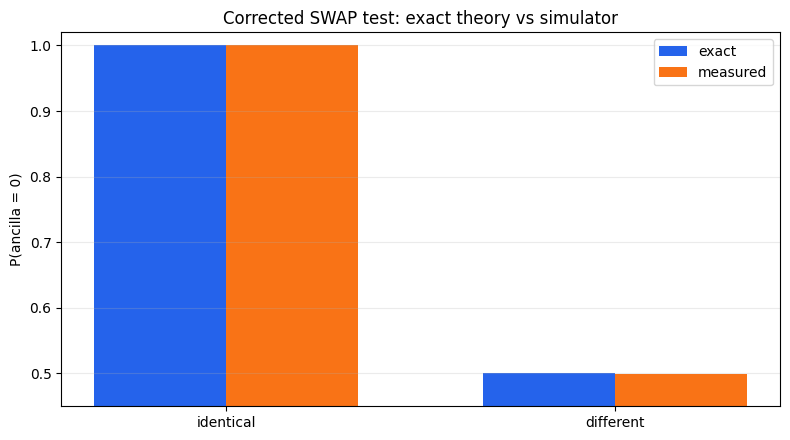

In [6]:
# Identical comparison: the same state against itself.
same_state = public_keys[0][0][int(message_bits[0])]
same_result = qds.swap_test(same_state, same_state)

# Different comparison: two public states from different bit positions.
state_a = public_keys[0][0][int(message_bits[0])]
state_b = public_keys[1][0][int(message_bits[1])]
different_result = qds.swap_test(state_a, state_b)

print("SWAP test results")
print("=" * 64)
print("Identical states")
print(f"  overlap squared       : {same_result['overlap_squared']:.6f}")
print(f"  exact P(ancilla=0)    : {same_result['p_zero_exact']:.6f}")
print(f"  measured P(ancilla=0) : {same_result['p_zero_measured']:.6f}")
print(f"  counts                : {same_result['counts']}")
print()
print("Different states")
print(f"  overlap squared       : {different_result['overlap_squared']:.6f}")
print(f"  exact P(ancilla=0)    : {different_result['p_zero_exact']:.6f}")
print(f"  measured P(ancilla=0) : {different_result['p_zero_measured']:.6f}")
print(f"  counts                : {different_result['counts']}")

labels = ["identical", "different"]
exact_values = [same_result["p_zero_exact"], different_result["p_zero_exact"]]
measured_values = [same_result["p_zero_measured"], different_result["p_zero_measured"]]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, exact_values, width, label="exact", color="#2563eb")
ax.bar(x + width / 2, measured_values, width, label="measured", color="#f97316")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.45, 1.02)
ax.set_ylabel("P(ancilla = 0)")
ax.set_title("Corrected SWAP test: exact theory vs simulator")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Sign the message

To sign a bit:

- If the bit is `0`, Alice reveals the `k0` key for each copy.
- If the bit is `1`, Alice reveals the `k1` key for each copy.

The opposite keys remain hidden. In this toy simulator the private keys
are still stored in memory, but the signed message object contains only
the revealed keys.

In [7]:
signed_message = qds.make_signature(message_bits)

print("Signed message")
print("=" * 64)
print(f"message : {signed_message['message']}")
print()
print("First three signed bit positions")
print("-" * 64)

for bit_index in range(3):
    bit_value = signed_message["signature"][bit_index]["bit_value"]
    print(f"bit index {bit_index}, message bit {bit_value}")
    for copy_index, key in enumerate(signed_message["signature"][bit_index]["keys"]):
        print(f"  copy {copy_index}: first 14 bits {key[:14]} ...")
    print()

total_revealed = len(message_bits) * qds.M
print(f"total revealed keys : {total_revealed}")
print(f"hidden opposite keys: {total_revealed}")

Signed message
message : 101100101

First three signed bit positions
----------------------------------------------------------------
bit index 0, message bit 1
  copy 0: first 14 bits [0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1] ...
  copy 1: first 14 bits [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1] ...
  copy 2: first 14 bits [0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0] ...
  copy 3: first 14 bits [1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1] ...
  copy 4: first 14 bits [0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1] ...

bit index 1, message bit 0
  copy 0: first 14 bits [1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] ...
  copy 1: first 14 bits [1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1] ...
  copy 2: first 14 bits [0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0] ...
  copy 3: first 14 bits [1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0] ...
  copy 4: first 14 bits [0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1] ...

bit index 2, message bit 1
  copy 0: first 14 bits [0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1] ...
  

## Step 7: Verify an honest signature

The verifier rebuilds the quantum state from each revealed key and
compares it with the stored public state for that message bit.

The old notebook counted failures across the whole message but compared
them only to `c1*M` and `c2*M`. This version compares failures to
`c1 * message_length * M` and `c2 * message_length * M`.

In [8]:
C1 = 0.10
C2 = 0.40

honest_result = qds.verify_signature(signed_message, c1=C1, c2=C2)

print("Honest verification")
print("=" * 64)
print(f"total checks        : {honest_result['total_checks']}")
print(f"failures            : {honest_result['failures']}")
print(f"failure rate        : {honest_result['failure_rate']:.6f}")
print(f"c1 threshold        : {honest_result['threshold_c1']:.2f}")
print(f"c2 threshold        : {honest_result['threshold_c2']:.2f}")
print(f"verdict             : {honest_result['verdict']}")
print(f"meaning             : {honest_result['verdict_full']}")
print()
print("Smallest exact pass probability:")
print(f"  {min(honest_result['pass_probabilities']):.12f}")

Honest verification
total checks        : 45
failures            : 0
failure rate        : 0.000000
c1 threshold        : 4.50
c2 threshold        : 18.00
verdict             : 1-ACC
meaning             : Accepted as valid and transferable.

Smallest exact pass probability:
  1.000000000000


## Step 8: Try a forged signature

A simple attacker does not know the hidden private keys, so they guess.
We demonstrate two protections:

1. A malformed packet is rejected before quantum checking.
2. A properly shaped but randomly guessed signature fails the quantum
   verification test.

Malformed tampering check
caught invalid packet: Signature bit metadata does not match the message at index 0.

Random-key forgery check
forged message      : 001100101
total checks        : 45
failures            : 45
failure rate        : 1.000000
c2 threshold        : 18.00
verdict             : REJ
meaning             : Rejected as invalid.


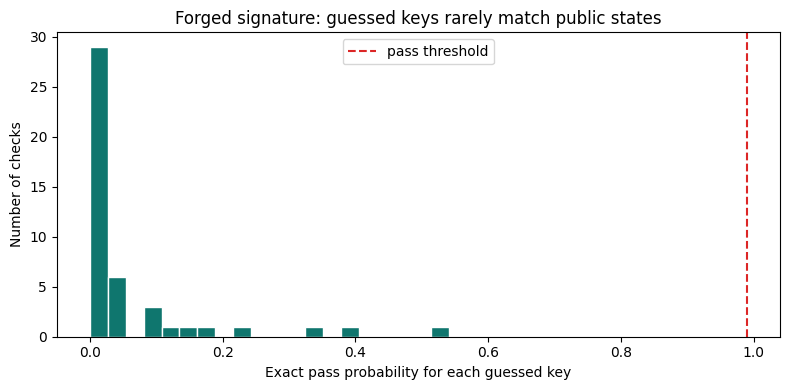

In [9]:
forged_message_bits = "001100101"  # first bit changed from 1 to 0

print("Malformed tampering check")
print("=" * 64)
try:
    qds.verify_signature(
        {"message": forged_message_bits, "signature": signed_message["signature"]},
        c1=C1,
        c2=C2,
    )
except ValueError as exc:
    print(f"caught invalid packet: {exc}")

print()
print("Random-key forgery check")
print("=" * 64)
forge_rng = np.random.default_rng(404)
forged_signature = qds.random_signature_guess(forged_message_bits, forge_rng)
forged_result = qds.verify_signature(forged_signature, c1=C1, c2=C2)

print(f"forged message      : {forged_message_bits}")
print(f"total checks        : {forged_result['total_checks']}")
print(f"failures            : {forged_result['failures']}")
print(f"failure rate        : {forged_result['failure_rate']:.6f}")
print(f"c2 threshold        : {forged_result['threshold_c2']:.2f}")
print(f"verdict             : {forged_result['verdict']}")
print(f"meaning             : {forged_result['verdict_full']}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(forged_result["pass_probabilities"], bins=20, color="#0f766e", edgecolor="white")
ax.axvline(qds.verification_pass_threshold, color="#dc2626", linestyle="--",
           label="pass threshold")
ax.set_xlabel("Exact pass probability for each guessed key")
ax.set_ylabel("Number of checks")
ax.set_title("Forged signature: guessed keys rarely match public states")
ax.legend()
plt.tight_layout()
plt.show()

## Step 9: Analyze forgery probability correctly

The old notebook plotted `p_avg ** M`, but its simulation accepted a
forgery when the number of failures was below the `c2` threshold. Those
are different events.

Here the analytical calculation uses the same rule as verification:

\[
\text{accept if failures} < c_2 \cdot \text{total_checks}.
\]

For independent random guesses, each check fails with probability
`q_fail = 1 - p_pass_average`. Therefore, the number of failures follows
a binomial distribution.

Forgery probability model
chunk sizes                 : [7, 7, 7, 7]
average pass probability    : 0.06250000
average failure probability : 0.93750000
acceptance threshold c2     : 0.4

Selected exact probabilities
----------------------------------------------------------------
M= 1 | one-bit accept=6.25000000e-02 | full-message accept=4.24531754e-06
M= 5 | one-bit accept=7.24792480e-05 | full-message accept=7.37910236e-23
M=10 | one-bit accept=3.77691322e-07 | full-message accept=7.32595462e-43
M=15 | one-bit accept=2.03922445e-09 | full-message accept=8.26768222e-63
M=20 | one-bit accept=1.13311683e-11 | full-message accept=9.85705779e-83


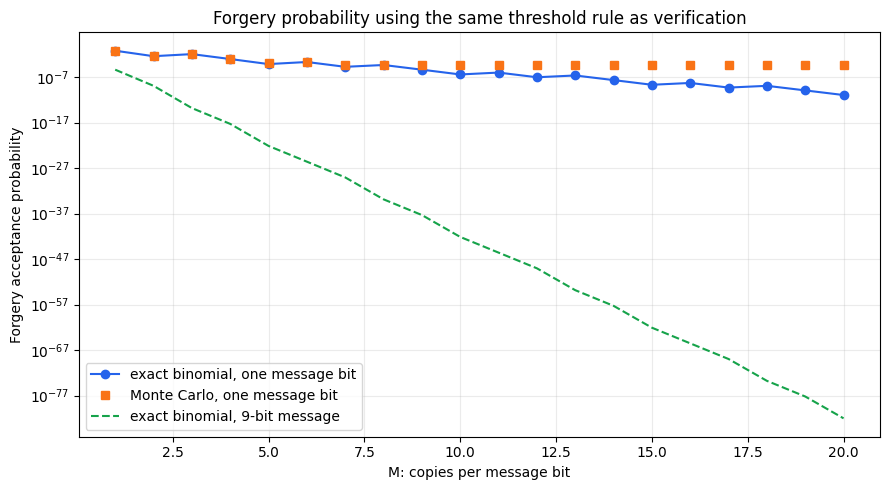

In [10]:
def average_chunk_overlap_squared(chunk_size: int) -> float:
    values = np.arange(2 ** chunk_size)
    theta = math.pi / (2 ** chunk_size)
    differences = values[:, None] - values[None, :]
    return float(np.mean(np.cos(differences * theta) ** 2))


def random_guess_pass_probability(chunk_sizes: List[int]) -> float:
    probability = 1.0
    for size in chunk_sizes:
        probability *= average_chunk_overlap_squared(size)
    return float(probability)


def accepted_failure_count(total_checks: int, c2: float) -> int:
    # Largest integer f such that f < c2 * total_checks.
    return math.ceil(c2 * total_checks) - 1


def binomial_accept_probability(total_checks: int, q_fail: float, c2: float) -> float:
    max_failures = accepted_failure_count(total_checks, c2)
    if max_failures < 0:
        return 0.0
    probability = 0.0
    for failures in range(max_failures + 1):
        probability += (
            math.comb(total_checks, failures)
            * (q_fail ** failures)
            * ((1.0 - q_fail) ** (total_checks - failures))
        )
    return float(probability)


p_pass_average = random_guess_pass_probability(qds.chunk_sizes)
q_fail_average = 1.0 - p_pass_average

M_values = np.arange(1, 21)
trials = 20_000
analysis_rng = np.random.default_rng(777)

exact_one_bit = []
monte_carlo_one_bit = []
exact_full_message = []

for M_value in M_values:
    total_one_bit = int(M_value)
    total_full_message = int(len(message_bits) * M_value)

    exact_one_bit.append(binomial_accept_probability(total_one_bit, q_fail_average, C2))
    exact_full_message.append(binomial_accept_probability(total_full_message, q_fail_average, C2))

    allowed = accepted_failure_count(total_one_bit, C2)
    sampled_failures = analysis_rng.binomial(total_one_bit, q_fail_average, size=trials)
    monte_carlo_one_bit.append(float(np.mean(sampled_failures <= allowed)))

print("Forgery probability model")
print("=" * 64)
print(f"chunk sizes                 : {qds.chunk_sizes}")
print(f"average pass probability    : {p_pass_average:.8f}")
print(f"average failure probability : {q_fail_average:.8f}")
print(f"acceptance threshold c2     : {C2}")
print()
print("Selected exact probabilities")
print("-" * 64)
for M_value in [1, 5, 10, 15, 20]:
    index = int(M_value - 1)
    print(
        f"M={M_value:2d} | one-bit accept={exact_one_bit[index]:.8e} "
        f"| full-message accept={exact_full_message[index]:.8e}"
    )

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(M_values, exact_one_bit, "o-", color="#2563eb",
            label="exact binomial, one message bit")
ax.semilogy(M_values, np.maximum(monte_carlo_one_bit, 1 / trials), "s",
            color="#f97316", label="Monte Carlo, one message bit")
ax.semilogy(M_values, np.maximum(exact_full_message, 1e-300), "--",
            color="#16a34a", label="exact binomial, 9-bit message")
ax.set_xlabel("M: copies per message bit")
ax.set_ylabel("Forgery acceptance probability")
ax.set_title("Forgery probability using the same threshold rule as verification")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Step 10: Summary

This corrected notebook fixes the main issues from the original version:

- The notebook is executable from a clean kernel.
- All private-key bits are used when building public states.
- The multi-qubit overlap formula matches the actual circuit.
- SWAP-test theory and simulation now agree up to normal shot noise.
- Verification thresholds scale with the full number of checks.
- Malformed signatures are rejected clearly.
- Forgery analysis uses the same threshold event as verification.
- Security language is more careful: this is a simulator demo, not a
  complete production QDS implementation.

The next step for a research-grade version would be to model separate
Alice, Bob, and Charlie objects, include noisy quantum channels, and add
automated tests outside the notebook.